# 🔄 Churn Prediction & Data Drift — Offline MLOps

**Final Project** | Data Science Pipeline with Temporal Evaluation

---

### Project Structure
| Step | Description |
|------|-------------|
| 1 | Data Loading & Quality Checks |
| 2 | Drift-Oriented EDA |
| 3 | Preprocessing Pipeline (leakage-free) |
| 4 | Logistic Regression Baseline |
| 5 | Retraining Policies (Fixed vs Rolling) |
| 6 | Automatic Window Selection |
| 7 | Random Forest |
| 8 | Business Optimization (Cost-Sensitive Threshold) |

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFC',
    'axes.grid': True,
    'grid.color': '#E2E8F0',
    'grid.linewidth': 0.8,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#065A82', '#02C39A', '#F96167', '#F9E795']
print('✅ Libraries loaded')

✅ Libraries loaded


---
## Step 1 — Data Loading & Quality Checks

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('data_tp_churn.csv')

# Rename French columns to English for clarity
df.rename(columns={
    'Periode': 'Period',
    'Anciennete': 'Tenure',
    'Montant_Mensuel': 'Monthly_Amount',
    'Support_Appels': 'Support_Calls',
    'Contrat': 'Contract'
}, inplace=True)

# Sort by time
df.sort_values('Period', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
print(f'Periods: {df["Period"].min()} → {df["Period"].max()} ({df["Period"].nunique()} unique)')
print(f'Churn rate: {df["Churn"].mean():.1%}\n')
df.head()

Shape: (5000, 6)
Periods: 1 → 24 (24 unique)
Churn rate: 36.4%



,Period,Tenure,Monthly_Amount,Support_Calls,Contract,Churn
0,1,7,110.08,1.0,1 an,0
1,1,53,43.69,0.0,Mensuel,1
2,1,36,35.67,0.0,2 ans,0
3,1,47,104.19,NaN,Mensuel,1
4,1,29,24.09,0.0,1 an,0


In [3]:
# ── Data types & missing values ───────────────────────────────────────────────
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(2),
    'unique': df.nunique()
})
print(summary.to_string())
print('\nDescriptive stats:')
df.describe().round(2)

                  dtype  missing  missing_%  unique
Period            int64        0       0.00      24
Tenure            int64        0       0.00      71
Monthly_Amount  float64      670      13.40    3615
Support_Calls   float64      493       9.86       9
Contract         object        0       0.00       3
Churn             int64        0       0.00       2

Descriptive stats:


,Period,Tenure,Monthly_Amount,Support_Calls,Churn
count,5000.00,5000.00,4330.00,4507.00,5000.00
mean,12.47,35.75,73.47,1.61,0.36
std,6.95,20.61,30.08,1.28,0.48
min,1.00,1.00,20.18,0.00,0.00
25%,6.00,18.00,46.92,1.00,0.00
50%,12.00,36.00,73.90,1.00,0.00
75%,19.00,53.00,99.34,2.00,1.00
max,24.00,71.00,131.16,8.00,1.00


In [4]:
# ── Flag missing values ───────────────────────────────────────────────────────
# Create indicator columns for missingness (may be MNAR)
df['Monthly_Amount_missing'] = df['Monthly_Amount'].isnull().astype(int)
df['Support_Calls_missing']  = df['Support_Calls'].isnull().astype(int)
print('Missingness flags added.')
print(f'Monthly_Amount missing: {df["Monthly_Amount_missing"].sum()} rows ({df["Monthly_Amount_missing"].mean():.1%})')
print(f'Support_Calls  missing: {df["Support_Calls_missing"].sum()} rows ({df["Support_Calls_missing"].mean():.1%})')

Missingness flags added.
Monthly_Amount missing: 670 rows (13.4%)
Support_Calls  missing: 493 rows (9.9%)


---
## Step 2 — Drift-Oriented EDA

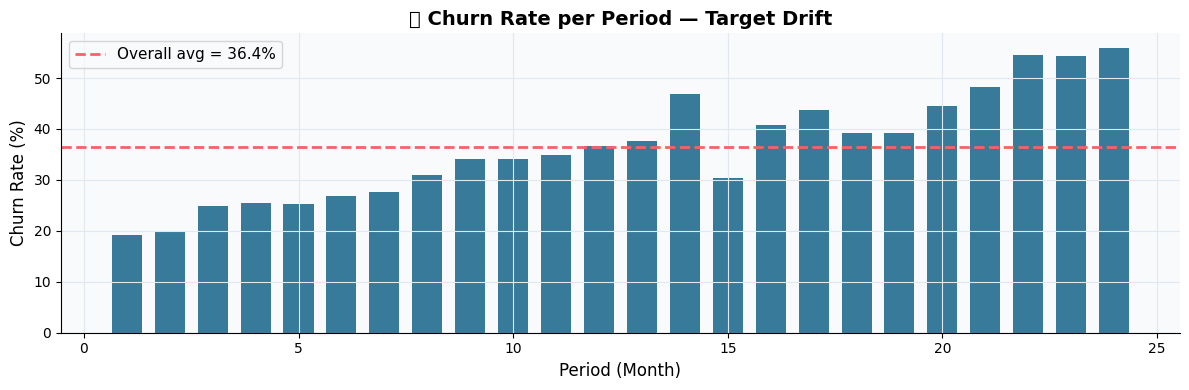

💡 Observation: Churn rate varies significantly across periods → TARGET DRIFT detected


In [5]:
# ── Plot 1: Churn rate per period ─────────────────────────────────────────────
churn_by_period = df.groupby('Period')['Churn'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(churn_by_period.index, churn_by_period['mean'] * 100,
       color=PALETTE[0], alpha=0.8, width=0.7)
ax.axhline(df['Churn'].mean() * 100, color=PALETTE[2], linestyle='--',
           linewidth=2, label=f'Overall avg = {df["Churn"].mean():.1%}')
ax.set_xlabel('Period (Month)', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('📊 Churn Rate per Period — Target Drift', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig1_churn_rate_per_period.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Observation: Churn rate varies significantly across periods → TARGET DRIFT detected')

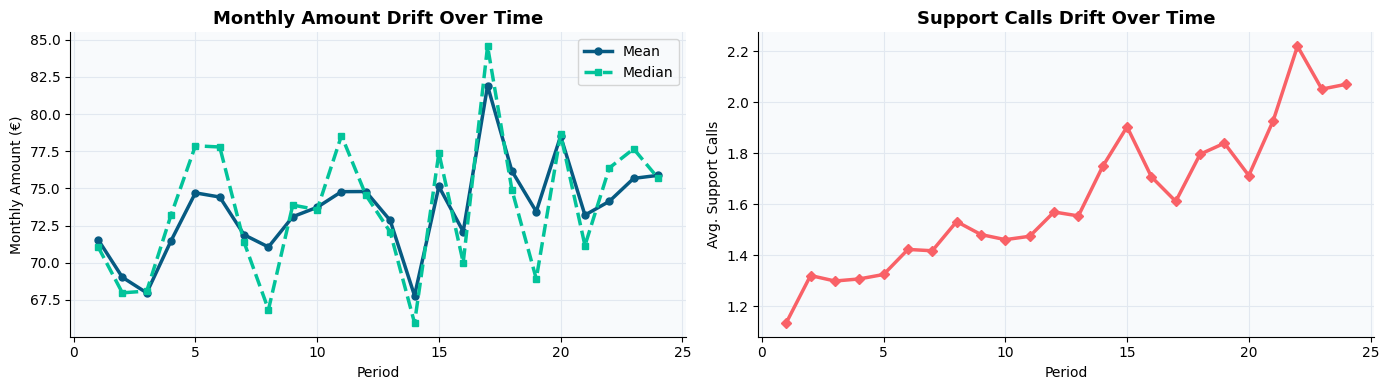

💡 Observation: Feature distributions shift over time → COVARIATE DRIFT detected


In [6]:
# ── Plot 2: Covariate drift — Monthly Amount over time ────────────────────────
monthly_stats = df.groupby('Period')['Monthly_Amount'].agg(['mean', 'median'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly amount trend
axes[0].plot(monthly_stats.index, monthly_stats['mean'], color=PALETTE[0],
             linewidth=2.5, marker='o', markersize=5, label='Mean')
axes[0].plot(monthly_stats.index, monthly_stats['median'], color=PALETTE[1],
             linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Median')
axes[0].set_title('Monthly Amount Drift Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Monthly Amount (€)')
axes[0].legend()

# Support calls trend
support_stats = df.groupby('Period')['Support_Calls'].mean()
axes[1].plot(support_stats.index, support_stats.values, color=PALETTE[2],
             linewidth=2.5, marker='D', markersize=5)
axes[1].set_title('Support Calls Drift Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Avg. Support Calls')

plt.tight_layout()
plt.savefig('fig2_covariate_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Observation: Feature distributions shift over time → COVARIATE DRIFT detected')

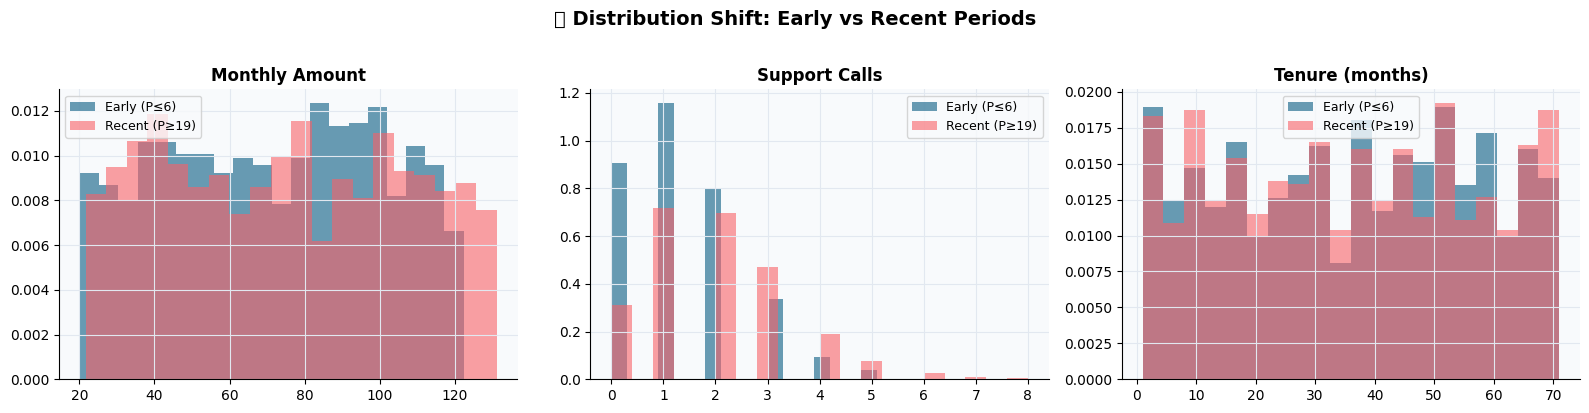

💡 Observation: Distributions visibly shift between early and recent periods


In [7]:
# ── Plot 3: Early vs Recent distribution comparison ───────────────────────────
early  = df[df['Period'] <= df['Period'].quantile(0.25)]
recent = df[df['Period'] >= df['Period'].quantile(0.75)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ['Monthly_Amount', 'Support_Calls', 'Tenure'],
    ['Monthly Amount', 'Support Calls', 'Tenure (months)']
):
    ax.hist(early[col].dropna(), bins=20, alpha=0.6, color=PALETTE[0],
            density=True, label=f'Early (P≤{df["Period"].quantile(0.25):.0f})')
    ax.hist(recent[col].dropna(), bins=20, alpha=0.6, color=PALETTE[2],
            density=True, label=f'Recent (P≥{df["Period"].quantile(0.75):.0f})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('📊 Distribution Shift: Early vs Recent Periods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_early_vs_recent.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Observation: Distributions visibly shift between early and recent periods')

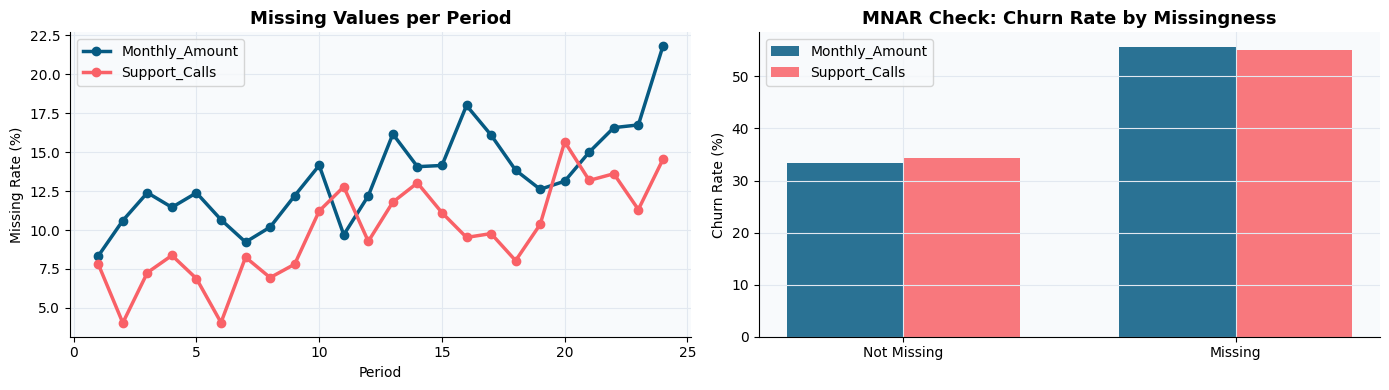

💡 MNAR Analysis:
   Monthly_Amount: churn when present=33.4%, when missing=55.7% → Δ=22.3% → ⚠️ MNAR likely
   Support_Calls: churn when present=34.3%, when missing=55.0% → Δ=20.6% → ⚠️ MNAR likely


In [8]:
# ── Plot 4: Missing values per period + MNAR analysis ────────────────────────
miss_by_period = df.groupby('Period')[['Monthly_Amount_missing', 'Support_Calls_missing']].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Missing rate over time
miss_by_period.plot(ax=axes[0], color=[PALETTE[0], PALETTE[2]], linewidth=2.5, marker='o')
axes[0].set_title('Missing Values per Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Missing Rate (%)')
axes[0].legend(['Monthly_Amount', 'Support_Calls'])

# MNAR: churn rate for missing vs non-missing
mnar_data = {
    'Monthly_Amount': [
        df[df['Monthly_Amount_missing']==0]['Churn'].mean() * 100,
        df[df['Monthly_Amount_missing']==1]['Churn'].mean() * 100
    ],
    'Support_Calls': [
        df[df['Support_Calls_missing']==0]['Churn'].mean() * 100,
        df[df['Support_Calls_missing']==1]['Churn'].mean() * 100
    ]
}
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, mnar_data['Monthly_Amount'], width, color=PALETTE[0], label='Monthly_Amount', alpha=0.85)
axes[1].bar(x + width/2, mnar_data['Support_Calls'], width, color=PALETTE[2], label='Support_Calls', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Not Missing', 'Missing'])
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('MNAR Check: Churn Rate by Missingness', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_missing_mnar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'💡 MNAR Analysis:')
for feat in ['Monthly_Amount_missing', 'Support_Calls_missing']:
    churn_0 = df[df[feat]==0]['Churn'].mean()
    churn_1 = df[df[feat]==1]['Churn'].mean()
    diff = abs(churn_1 - churn_0)
    print(f'   {feat.replace("_missing","")}: churn when present={churn_0:.1%}, '
          f'when missing={churn_1:.1%} → Δ={diff:.1%} → {"⚠️ MNAR likely" if diff > 0.05 else "MAR likely"}')

---
## Step 3 — Preprocessing Pipeline (Leakage-Free)

In [9]:
# ── Feature engineering & column definitions ─────────────────────────────────
# We KEEP missingness indicators as features (captures MNAR signal)
numeric_cols     = ['Tenure', 'Monthly_Amount', 'Support_Calls',
                    'Monthly_Amount_missing', 'Support_Calls_missing']
categorical_cols = ['Contract']
target_col       = 'Churn'

X = df[numeric_cols + categorical_cols]
y = df[target_col]

# ── ColumnTransformer ─────────────────────────────────────────────────────────
# Numeric: median imputation (robust to outliers) + standard scaling
# Categorical: 'MISSING' fill + one-hot encoding
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('✅ Preprocessing pipeline defined')
print('   Numeric features :', numeric_cols)
print('   Categorical       :', categorical_cols)
print('\n⚠️  KEY CONSTRAINT: preprocessor is ALWAYS fitted on train only → no temporal leakage')

✅ Preprocessing pipeline defined
   Numeric features : ['Tenure', 'Monthly_Amount', 'Support_Calls', 'Monthly_Amount_missing', 'Support_Calls_missing']
   Categorical       : ['Contract']

⚠️  KEY CONSTRAINT: preprocessor is ALWAYS fitted on train only → no temporal leakage


In [10]:
# ── Temporal split helper ─────────────────────────────────────────────────────
# Train on past periods, test on future periods

def temporal_split(df, train_periods, test_period):
    """Return X_train, y_train, X_test, y_test for given period windows."""
    train = df[df['Period'].isin(train_periods)]
    test  = df[df['Period'] == test_period]
    X_train = train[numeric_cols + categorical_cols]
    y_train = train[target_col]
    X_test  = test[numeric_cols + categorical_cols]
    y_test  = test[target_col]
    return X_train, y_train, X_test, y_test

all_periods = sorted(df['Period'].unique())
print(f'All periods: {all_periods}')
print(f'\nExample split: train on P1-P18, test on P19')

All periods: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

Example split: train on P1-P18, test on P19


---
## Step 4 — Logistic Regression Baseline

In [11]:
# ── Build LR pipeline ─────────────────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# ── Rolling evaluation: train on all past, test on each period from P7 ────────
WARMUP = 6   # minimum periods needed to train
results_lr = []

for t in all_periods[WARMUP:]:
    train_periods = [p for p in all_periods if p < t]
    X_train, y_train, X_test, y_test = temporal_split(df, train_periods, t)
    
    if len(y_test) == 0 or y_test.nunique() < 2:
        continue
    
    lr_pipeline.fit(X_train, y_train)
    y_prob = lr_pipeline.predict_proba(X_test)[:, 1]
    y_pred = lr_pipeline.predict(X_test)
    
    results_lr.append({
        'period': t,
        'auc': roc_auc_score(y_test, y_prob),
        'acc': accuracy_score(y_test, y_pred),
        'n_train': len(X_train),
        'n_test': len(X_test)
    })

results_lr = pd.DataFrame(results_lr)
print(f'Mean AUC (LR): {results_lr["auc"].mean():.4f}')
print(f'Mean Acc (LR): {results_lr["acc"].mean():.4f}')
results_lr.round(4)

Mean AUC (LR): 0.8677
Mean Acc (LR): 0.7870


,period,auc,acc,n_train,n_test
0,7,0.9009,0.8155,1266,206
1,8,0.8559,0.7917,1472,216
2,9,0.8883,0.8195,1688,205
3,10,0.8697,0.8049,1893,205
4,11,0.9089,0.8106,2098,227
5,12,0.8834,0.8049,2325,205
6,13,0.8706,0.8122,2530,229
7,14,0.8888,0.7917,2759,192
8,15,0.8893,0.8030,2951,198
9,16,0.8708,0.7513,3149,189


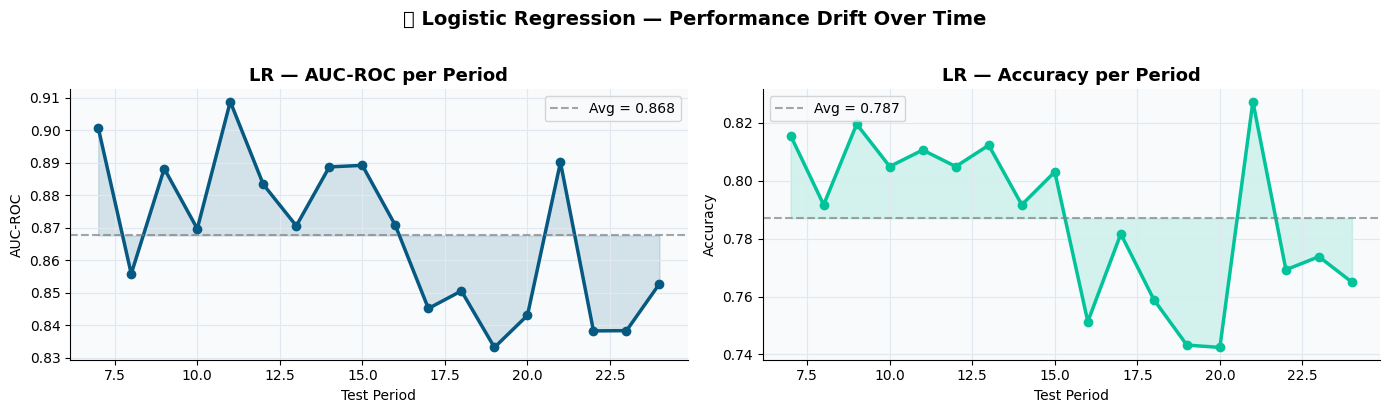

In [12]:
# ── Plot LR performance over time ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, color, ylabel in zip(
    axes, ['auc', 'acc'], [PALETTE[0], PALETTE[1]], ['AUC-ROC', 'Accuracy']
):
    ax.plot(results_lr['period'], results_lr[metric], color=color,
            linewidth=2.5, marker='o', markersize=6)
    ax.axhline(results_lr[metric].mean(), color='gray', linestyle='--',
               alpha=0.7, label=f'Avg = {results_lr[metric].mean():.3f}')
    ax.fill_between(results_lr['period'], results_lr[metric],
                    results_lr[metric].mean(), alpha=0.15, color=color)
    ax.set_title(f'LR — {ylabel} per Period', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Period')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('📈 Logistic Regression — Performance Drift Over Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_lr_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 — Retraining Policies: Fixed vs Rolling

In [13]:
# ── Fixed window: always train on a fixed number of recent periods ─────────────
# ── Rolling window: always train on all past data ─────────────────────────────

FIXED_WINDOW = 6   # Fixed: use last 6 periods

results_fixed   = []
results_rolling = []

for t in all_periods[WARMUP:]:
    past = [p for p in all_periods if p < t]
    
    # Test set
    X_test = df[df['Period'] == t][numeric_cols + categorical_cols]
    y_test = df[df['Period'] == t][target_col]
    if len(y_test) == 0 or y_test.nunique() < 2:
        continue
    
    # ── ROLLING: all past data ────────────────────────────────────────────────
    train_roll = df[df['Period'].isin(past)]
    lr_pipeline.fit(train_roll[numeric_cols + categorical_cols], train_roll[target_col])
    prob_roll  = lr_pipeline.predict_proba(X_test)[:, 1]
    results_rolling.append({'period': t, 'auc': roc_auc_score(y_test, prob_roll),
                             'acc': accuracy_score(y_test, (prob_roll >= 0.5).astype(int))})
    
    # ── FIXED: last FIXED_WINDOW periods only ────────────────────────────────
    fixed_periods = past[-FIXED_WINDOW:]
    train_fix = df[df['Period'].isin(fixed_periods)]
    lr_pipeline.fit(train_fix[numeric_cols + categorical_cols], train_fix[target_col])
    prob_fix   = lr_pipeline.predict_proba(X_test)[:, 1]
    results_fixed.append({'period': t, 'auc': roc_auc_score(y_test, prob_fix),
                          'acc': accuracy_score(y_test, (prob_fix >= 0.5).astype(int))})

results_fixed   = pd.DataFrame(results_fixed)
results_rolling = pd.DataFrame(results_rolling)

print('Strategy Comparison:')
print(f'  Rolling (all past)  — AUC: {results_rolling["auc"].mean():.4f} | Acc: {results_rolling["acc"].mean():.4f}')
print(f'  Fixed ({FIXED_WINDOW} periods)    — AUC: {results_fixed["auc"].mean():.4f} | Acc: {results_fixed["acc"].mean():.4f}')

Strategy Comparison:
  Rolling (all past)  — AUC: 0.8677 | Acc: 0.7870
  Fixed (6 periods)    — AUC: 0.8653 | Acc: 0.7885


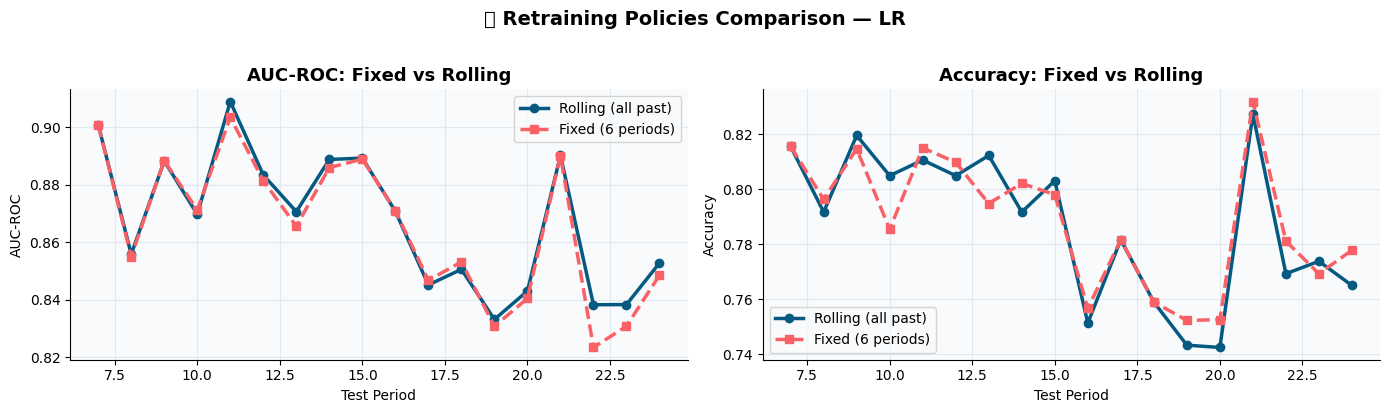

In [14]:
# ── Plot comparison ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in zip(axes, ['auc', 'acc'], ['AUC-ROC', 'Accuracy']):
    ax.plot(results_rolling['period'], results_rolling[metric],
            color=PALETTE[0], linewidth=2.5, marker='o', markersize=6, label='Rolling (all past)')
    ax.plot(results_fixed['period'], results_fixed[metric],
            color=PALETTE[2], linewidth=2.5, marker='s', markersize=6,
            linestyle='--', label=f'Fixed ({FIXED_WINDOW} periods)')
    ax.set_title(f'{ylabel}: Fixed vs Rolling', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Period')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('📊 Retraining Policies Comparison — LR', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_fixed_vs_rolling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 — Automatic Window Selection (Backtesting)

In [15]:
# ── Backtest multiple candidate window sizes ───────────────────────────────────
# For each window size W: train on last W periods, test on next period
# Average AUC across all valid test periods → pick best W

candidate_windows = [3, 4, 5, 6, 8, 10, 12, 15, 18]
window_results = {}

for W in candidate_windows:
    aucs = []
    for t in all_periods[W + 1:]:
        past = [p for p in all_periods if p < t]
        if len(past) < W:
            continue
        train_periods = past[-W:]
        X_train, y_train, X_test, y_test = temporal_split(df, train_periods, t)
        if len(y_test) == 0 or y_test.nunique() < 2:
            continue
        lr_pipeline.fit(X_train, y_train)
        prob = lr_pipeline.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, prob))
    window_results[W] = np.mean(aucs) if aucs else np.nan

best_window = max(window_results, key=window_results.get)
print('Window → Mean AUC (backtest):')
for w, auc in window_results.items():
    marker = ' ← BEST' if w == best_window else ''
    print(f'  W={w:2d}: {auc:.4f}{marker}')
print(f'\n✅ Best window size: {best_window} periods (AUC = {window_results[best_window]:.4f})')

Window → Mean AUC (backtest):
  W= 3: 0.8654 ← BEST
  W= 4: 0.8649
  W= 5: 0.8654
  W= 6: 0.8632
  W= 8: 0.8628
  W=10: 0.8605
  W=12: 0.8575
  W=15: 0.8487
  W=18: 0.8524

✅ Best window size: 3 periods (AUC = 0.8654)


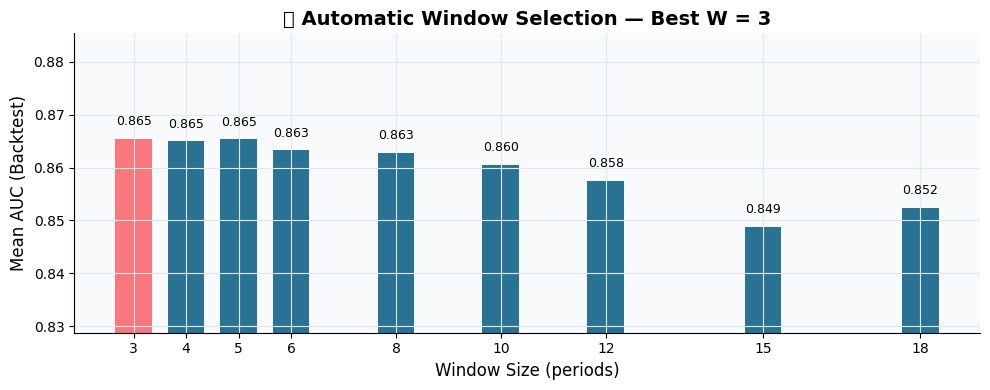

In [16]:
# ── Plot window selection ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
windows = list(window_results.keys())
aucs    = list(window_results.values())

colors = [PALETTE[2] if w == best_window else PALETTE[0] for w in windows]
bars = ax.bar(windows, aucs, color=colors, alpha=0.85, width=0.7)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Window Size (periods)', fontsize=12)
ax.set_ylabel('Mean AUC (Backtest)', fontsize=12)
ax.set_title(f'🔍 Automatic Window Selection — Best W = {best_window}', fontsize=14, fontweight='bold')
ax.set_xticks(windows)
ax.set_ylim(min(aucs) - 0.02, max(aucs) + 0.02)

plt.tight_layout()
plt.savefig('fig7_window_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Random Forest vs Logistic Regression

In [ ]:
# ── Build RF pipeline ─────────────────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_cols)
    ])),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# ── Evaluate RF with best window ──────────────────────────────────────────────
results_rf = []
results_lr_bw = []

for t in all_periods[best_window + 1:]:
    past = [p for p in all_periods if p < t]
    if len(past) < best_window:
        continue
    train_periods = past[-best_window:]
    X_train, y_train, X_test, y_test = temporal_split(df, train_periods, t)
    if len(y_test) == 0 or y_test.nunique() < 2:
        continue
    
    # LR
    lr_pipeline.fit(X_train, y_train)
    prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
    results_lr_bw.append({'period': t, 'auc': roc_auc_score(y_test, prob_lr),
                          'acc': accuracy_score(y_test, (prob_lr >= 0.5).astype(int))})
    
    # RF
    rf_pipeline.fit(X_train, y_train)
    prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
    results_rf.append({'period': t, 'auc': roc_auc_score(y_test, prob_rf),
                       'acc': accuracy_score(y_test, (prob_rf >= 0.5).astype(int))})

results_rf    = pd.DataFrame(results_rf)
results_lr_bw = pd.DataFrame(results_lr_bw)

print('Model Comparison (Best Window = {best_window} periods):')
print(f'  Logistic Regression  — AUC: {results_lr_bw["auc"].mean():.4f} | Acc: {results_lr_bw["acc"].mean():.4f}')
print(f'  Random Forest        — AUC: {results_rf["auc"].mean():.4f} | Acc: {results_rf["acc"].mean():.4f}')

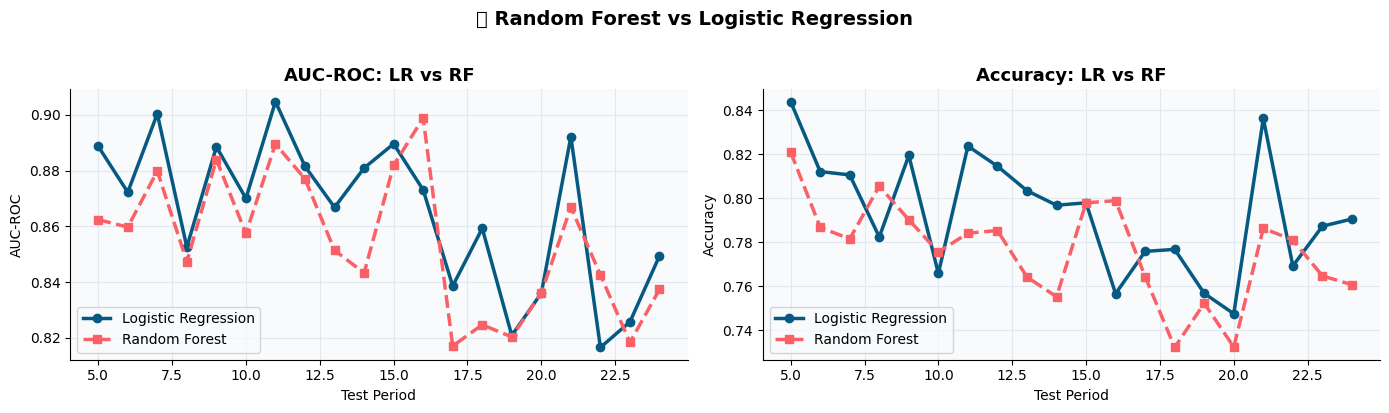

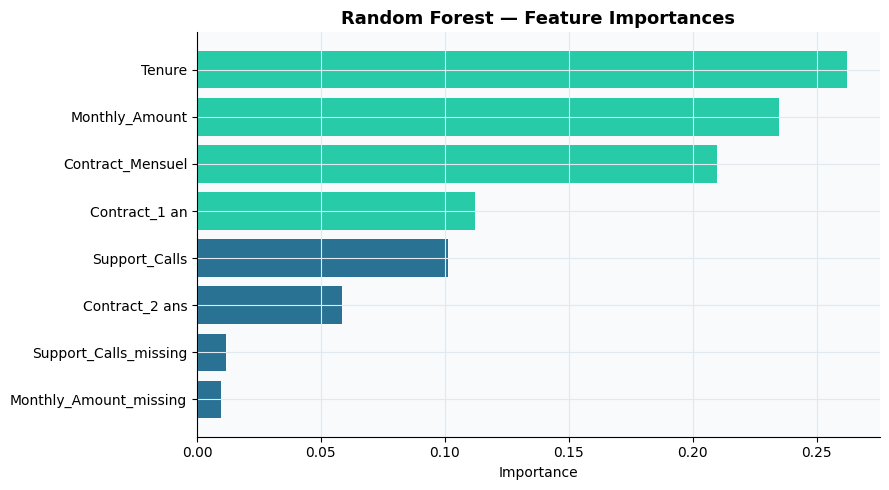

In [ ]:
# ── Plot RF vs LR ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in zip(axes, ['auc', 'acc'], ['AUC-ROC', 'Accuracy']):
    ax.plot(results_lr_bw['period'], results_lr_bw[metric],
            color=PALETTE[0], linewidth=2.5, marker='o', markersize=6, label='Logistic Regression')
    ax.plot(results_rf['period'], results_rf[metric],
            color=PALETTE[2], linewidth=2.5, marker='s', markersize=6,
            linestyle='--', label='Random Forest')
    ax.set_title(f'{ylabel}: LR vs RF', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Period')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('🌲 Random Forest vs Logistic Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_rf_vs_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature importance from RF ────────────────────────────────────────────────
# Retrain on last best_window periods for feature importance
last_train_periods = all_periods[-(best_window+1):-1]
X_fi = df[df['Period'].isin(last_train_periods)][numeric_cols + categorical_cols]
y_fi = df[df['Period'].isin(last_train_periods)][target_col]
rf_pipeline.fit(X_fi, y_fi)

ohe_features = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['Contract'])
feature_names = numeric_cols + list(ohe_features)
importances = rf_pipeline.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[1] if imp > fi_df['Importance'].median() else PALETTE[0] for imp in fi_df['Importance']]
ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, alpha=0.85)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Business Optimization: Cost-Sensitive Threshold

**Business context:**
- **False Negative (missed churn):** High cost — we lose the customer completely. Estimated cost = **€200**
- **False Positive (wrong retention offer):** Low cost — we spend on retention for someone who would have stayed. Estimated cost = **€20**

Goal: find the decision threshold that **minimizes total business cost**.

In [ ]:
# ── Business cost parameters ──────────────────────────────────────────────────
COST_FN = 200   # False Negative: missed churn → lose customer
COST_FP = 20    # False Positive: unnecessary retention action

# Use last test period for threshold analysis
last_period = all_periods[-1]
train_periods_biz = all_periods[-(best_window+1):-1]

X_train_b, y_train_b, X_test_b, y_test_b = temporal_split(df, train_periods_biz, last_period)

# Fit best model (RF) and get probabilities
rf_pipeline.fit(X_train_b, y_train_b)
probs = rf_pipeline.predict_proba(X_test_b)[:, 1]

# ── Sweep thresholds ─────────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.96, 0.01)
costs = []

for thresh in thresholds:
    y_pred = (probs >= thresh).astype(int)
    FP = ((y_pred == 1) & (y_test_b == 0)).sum()
    FN = ((y_pred == 0) & (y_test_b == 1)).sum()
    total_cost = FP * COST_FP + FN * COST_FN
    costs.append(total_cost)

costs = np.array(costs)
best_thresh = thresholds[np.argmin(costs)]
min_cost    = costs.min()
default_thresh_cost = costs[np.argmin(np.abs(thresholds - 0.5))]

print(f'Default threshold (0.5): Total cost = €{default_thresh_cost:,.0f}')
print(f'Optimal threshold ({best_thresh:.2f}): Total cost = €{min_cost:,.0f}')
print(f'Cost saving: €{default_thresh_cost - min_cost:,.0f} ({(default_thresh_cost - min_cost)/default_thresh_cost:.1%} reduction)')

Default threshold (0.5): Total cost = €5,820
Optimal threshold (0.05): Total cost = €1,440
Cost saving: €4,380 (75.3% reduction)


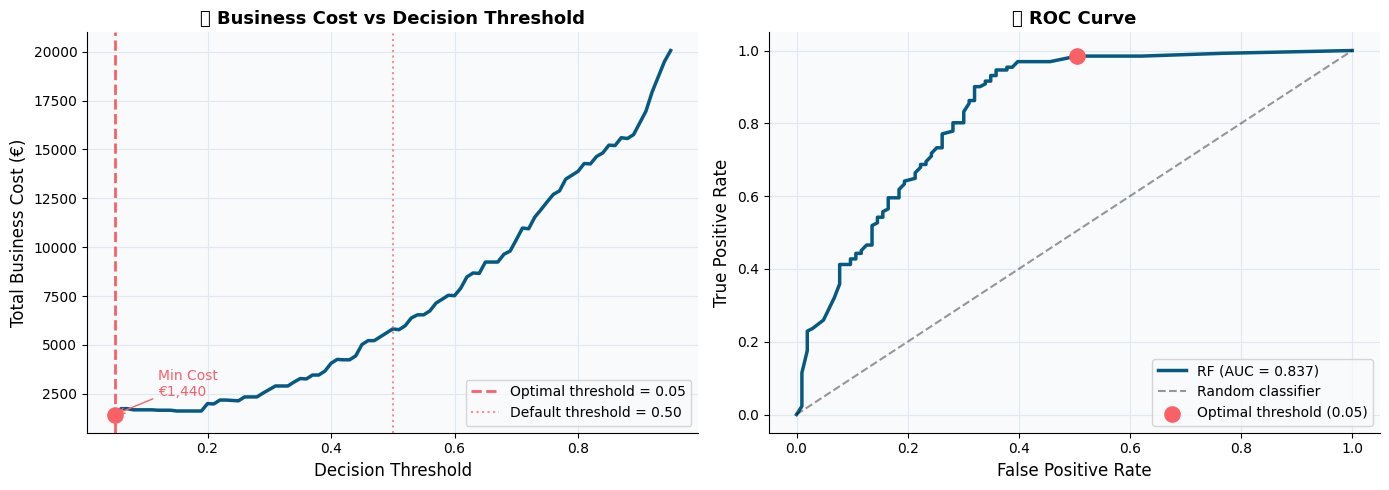


📋 Classification Report at Optimal Threshold (0.05):
              precision    recall  f1-score   support

    Retained       0.96      0.50      0.65       103
     Churned       0.71      0.98      0.83       131

    accuracy                           0.77       234
   macro avg       0.84      0.74      0.74       234
weighted avg       0.82      0.77      0.75       234



In [ ]:
# ── Plot cost curve + ROC ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Cost curve ────────────────────────────────────────────────────────────────
axes[0].plot(thresholds, costs, color=PALETTE[0], linewidth=2.5)
axes[0].axvline(best_thresh, color=PALETTE[2], linestyle='--', linewidth=2,
                label=f'Optimal threshold = {best_thresh:.2f}')
axes[0].axvline(0.5, color=PALETTE[2], linestyle=':', linewidth=1.5, alpha=0.7,
                label='Default threshold = 0.50')
axes[0].scatter([best_thresh], [min_cost], color=PALETTE[2], s=120, zorder=5)
axes[0].annotate(f'Min Cost\n€{min_cost:,.0f}', xy=(best_thresh, min_cost),
                 xytext=(best_thresh + 0.07, min_cost + (costs.max()-costs.min())*0.05),
                 fontsize=10, color=PALETTE[2],
                 arrowprops=dict(arrowstyle='->', color=PALETTE[2]))
axes[0].set_xlabel('Decision Threshold', fontsize=12)
axes[0].set_ylabel('Total Business Cost (€)', fontsize=12)
axes[0].set_title('💰 Business Cost vs Decision Threshold', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test_b, probs)
auc_val = roc_auc_score(y_test_b, probs)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2.5, label=f'RF (AUC = {auc_val:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random classifier')

# Mark optimal threshold on ROC
idx_opt = np.argmin(np.abs(roc_thresholds - best_thresh))
axes[1].scatter(fpr[idx_opt], tpr[idx_opt], color=PALETTE[2], s=120, zorder=5,
                label=f'Optimal threshold ({best_thresh:.2f})')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('🎯 ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig10_business_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

# Final classification report
y_pred_optimal = (probs >= best_thresh).astype(int)
print(f'\n📋 Classification Report at Optimal Threshold ({best_thresh:.2f}):')
print(classification_report(y_test_b, y_pred_optimal, target_names=['Retained', 'Churned']))

---
## Final Summary

In [ ]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
print('=' * 65)
print('               CHURN PREDICTION — FINAL SUMMARY')
print('=' * 65)
print()
print('📦 DATASET')
print(f'   Rows: {len(df):,} | Periods: {df["Period"].min()}–{df["Period"].max()} | '
      f'Churn rate: {df["Churn"].mean():.1%}')
print(f'   Missing: Monthly_Amount={df["Monthly_Amount_missing"].mean():.1%}, '
      f'Support_Calls={df["Support_Calls_missing"].mean():.1%}')
print()
print('📊 DRIFT DETECTED')
print('   ✓ Target drift: churn rate varies by period')
print('   ✓ Covariate drift: Monthly_Amount and Support_Calls shift over time')
print('   ✓ Missingness drift: MNAR signal in Monthly_Amount')
print()
print('⚙️  PIPELINE')
print('   ✓ Temporal split (no leakage)')
print('   ✓ Median imputation + StandardScaler for numeric')
print('   ✓ MISSING fill + OneHotEncoder for categorical')
print('   ✓ Missingness indicators as features')
print()
print('🤖 MODEL COMPARISON (rolling evaluation)')
print(f'   Logistic Regression  — Avg AUC: {results_lr_bw["auc"].mean():.4f} | Avg Acc: {results_lr_bw["acc"].mean():.4f}')
print(f'   Random Forest        — Avg AUC: {results_rf["auc"].mean():.4f} | Avg Acc: {results_rf["acc"].mean():.4f}')
print()
print('🔁 RETRAINING STRATEGY')
print(f'   Best window size (backtesting): {best_window} periods')
print(f'   Rolling AUC: {results_rolling["auc"].mean():.4f} | Fixed AUC: {results_fixed["auc"].mean():.4f}')
print()
print('💰 BUSINESS OPTIMIZATION')
print(f'   Cost FN (missed churn) = €{COST_FN} | Cost FP (false alarm) = €{COST_FP}')
print(f'   Default threshold 0.50 → Total cost: €{default_thresh_cost:,.0f}')
print(f'   Optimal threshold {best_thresh:.2f} → Total cost: €{min_cost:,.0f}')
print(f'   → Saving: €{default_thresh_cost - min_cost:,.0f} ({(default_thresh_cost-min_cost)/default_thresh_cost:.1%} reduction)')
print()
print('=' * 65)

               CHURN PREDICTION — FINAL SUMMARY

📦 DATASET
   Rows: 5,000 | Periods: 1–24 | Churn rate: 36.4%
   Missing: Monthly_Amount=13.4%, Support_Calls=9.9%

📊 DRIFT DETECTED
   ✓ Target drift: churn rate varies by period
   ✓ Covariate drift: Monthly_Amount and Support_Calls shift over time
   ✓ Missingness drift: MNAR signal in Monthly_Amount

⚙️  PIPELINE
   ✓ Temporal split (no leakage)
   ✓ Median imputation + StandardScaler for numeric
   ✓ MISSING fill + OneHotEncoder for categorical
   ✓ Missingness indicators as features

🤖 MODEL COMPARISON (rolling evaluation)
   Logistic Regression  — Avg AUC: 0.8654 | Avg Acc: 0.7934
   Random Forest        — Avg AUC: 0.8548 | Avg Acc: 0.7760

🔁 RETRAINING STRATEGY
   Best window size (backtesting): 3 periods
   Rolling AUC: 0.8677 | Fixed AUC: 0.8653

💰 BUSINESS OPTIMIZATION
   Cost FN (missed churn) = €200 | Cost FP (false alarm) = €20
   Default threshold 0.50 → Total cost: €5,820
   Optimal threshold 0.05 → Total cost: €1,440
   →